In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

In [4]:
df=pd.read_csv("/content/Mall_Customers.csv")
print(df.shape)
print(df.dtypes)
df.head()

(200, 5)
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


**Observation**:
The dataset has 200 rows and no missing values, so no imputation is needed.

We'll drop CustomerID (identifier, not useful for clustering) and focus on the three recommended numeric features: Age, Annual Income (k$), Spending Score (1-100).

In [6]:
df= df.drop(columns=["CustomerID"])

In [7]:
label_ecoder=LabelEncoder()
df["Gender_encoded"] = label_ecoder.fit_transform(df["Gender"])

df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_encoded
0,Male,19,15,39,1
1,Male,21,15,81,1
2,Female,20,16,6,0
3,Female,23,16,77,0
4,Female,31,17,40,0
...,...,...,...,...,...
195,Female,35,120,79,0
196,Female,45,126,28,0
197,Male,32,126,74,1
198,Male,32,137,18,1


In [8]:
scaled=StandardScaler()
scaled_feu=scaled.fit_transform(df[['Age','Annual Income (k$)','Spending Score (1-100)']])
scaled_df = pd.DataFrame(scaled_feu, columns=["Age_scaled","Income(k$)_scaled","Spending_scaled"])

scaled_df

,Age_scaled,Income(k$)_scaled,Spending_scaled
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


2. Apply Clustering Algorithms

KMEAN

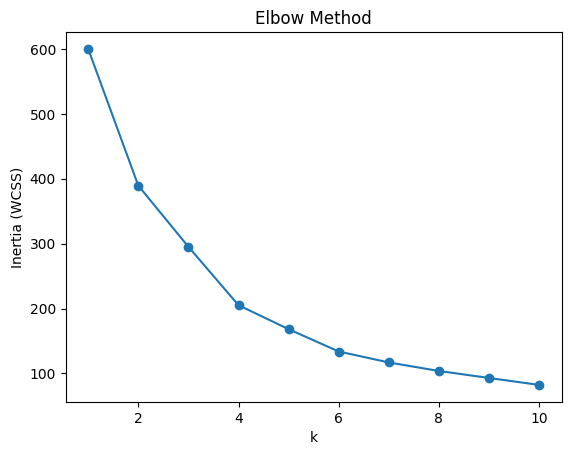

In [9]:
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_feu)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.show()


In [10]:

sil_scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_feu)
    score = silhouette_score(scaled_feu, labels)
    sil_scores.append(score)
    print(f"k={k}: silhouette = {score:.4f}")

k=2: silhouette = 0.3355
k=3: silhouette = 0.3578
k=4: silhouette = 0.4040
k=5: silhouette = 0.4166
k=6: silhouette = 0.4284
k=7: silhouette = 0.4172
k=8: silhouette = 0.4082


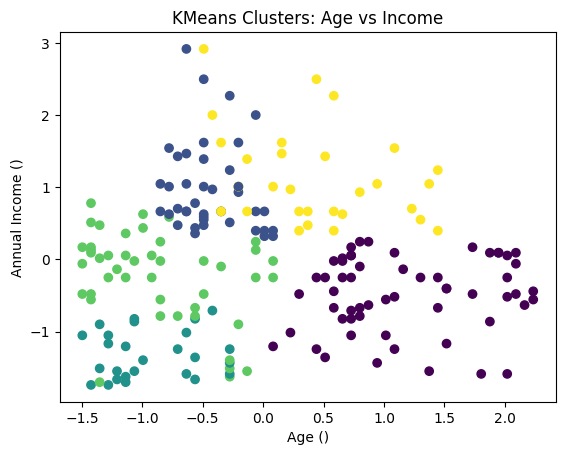

In [31]:
Kmean = KMeans(n_clusters=5, random_state=42)
cluster = Kmean.fit_predict(scaled_feu)
plt.scatter(scaled_feu[:,0],scaled_feu[:,1],c=cluster,cmap="viridis")
plt.xlabel("Age ()")
plt.ylabel("Annual Income ()")
plt.title("KMeans Clusters: Age vs Income")
plt.show()


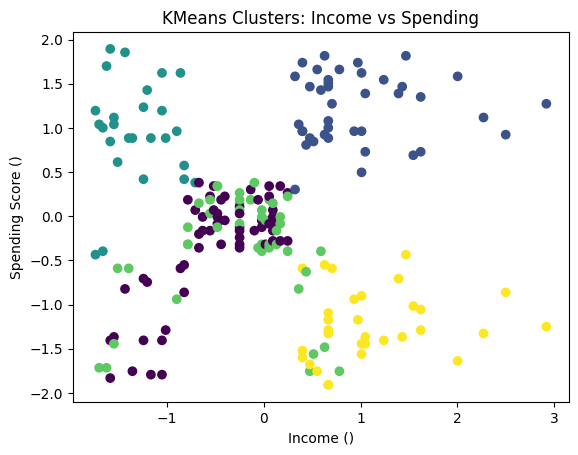

In [32]:
plt.scatter(scaled_feu[:,1], scaled_feu[:,2], c=cluster, cmap="viridis")
plt.xlabel("Income ()")
plt.ylabel("Spending Score ()")
plt.title("KMeans Clusters: Income vs Spending")
plt.show()

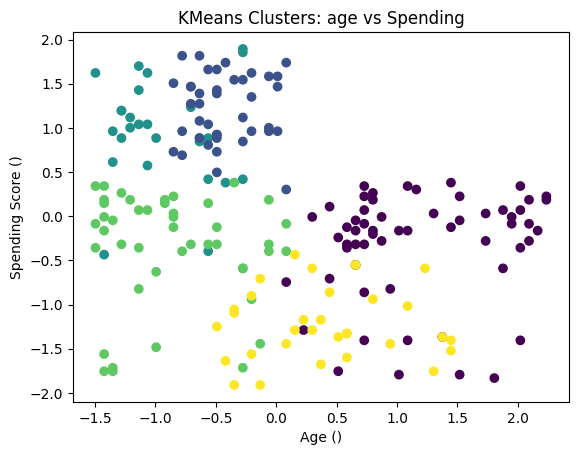

In [33]:
plt.scatter(scaled_feu[:,0], scaled_feu[:,2], c=cluster, cmap="viridis")
plt.xlabel("Age ()")
plt.ylabel("Spending Score ()")
plt.title("KMeans Clusters: age vs Spending")
plt.show()

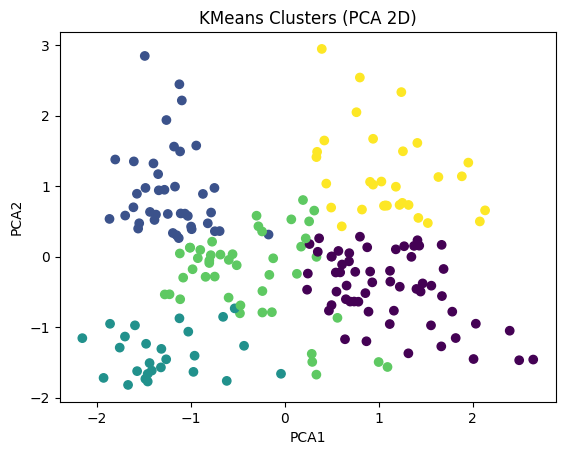

0.7757454566976747


In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaled_feu)

plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster, cmap="viridis")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("KMeans Clusters (PCA 2D)")
plt.show()

print(pca.explained_variance_ratio_.sum())

K-Means: When you expect roughly round, evenly-sized clusters, you have a rough idea of (or can estimate) the number of segments, and you're working with a large dataset where speed matters.

**Strengths**
Fast, scalable, simple, easy to interpret centroids/Kmen
**Weaknesses**
Needs K chosen upfront, assumes spherical clusters, sensitive to outliers and initialization/Kmen